In [1]:
!pip install -q mlflow
!pip install -q --no-cache-dir --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git@main

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
print("--- hybride.py sur GitHub (main) ---")
!curl -s https://raw.githubusercontent.com/RayenSansa03/aeroguard/main/src/aeroguard/hybride.py | grep -n "^def "
print("\n--- hybride.py installé dans Colab ---")
!grep -n "^def " $(python -c "import aeroguard, os; print(os.path.dirname(aeroguard.__file__))")/hybride.py

--- hybride.py sur GitHub (main) ---

--- hybride.py installé dans Colab ---
grep: /usr/local/lib/python3.13/dist-packages/aeroguard/hybride.py: No such file or directory


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import math
import os
import shutil
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
DOSSIER_MLFLOW_LOCAL = "/content/mlflow"
DOSSIER_MLFLOW_DRIVE = f"{DOSSIER}/mlflow"
if os.path.exists(DOSSIER_MLFLOW_DRIVE) and not os.path.exists(DOSSIER_MLFLOW_LOCAL):
    shutil.copytree(DOSSIER_MLFLOW_DRIVE, DOSSIER_MLFLOW_LOCAL)
if os.path.exists(f"{DOSSIER}/mlruns") and not os.path.exists("/content/mlruns"):
    shutil.copytree(f"{DOSSIER}/mlruns", "/content/mlruns")
os.makedirs(DOSSIER_MLFLOW_LOCAL, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{DOSSIER_MLFLOW_LOCAL}/mlflow.db")

vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")
X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

# Tous les vols HORS TEST (le test reste fermé jusqu'à la 5.6)
X_hors_test = pd.concat([X_train, X_val])
y_np = pd.concat([y_train, y_val]).to_numpy()
infos_hors_test = vols.loc[X_hors_test.index, ["moteur", "cycle", "RUL"]]
famille = vols.loc[X_hors_test.index, "famille"].astype(str).to_numpy()
groupe = vols.loc[X_hors_test.index, "groupe"].to_numpy()
assert not X_hors_test.isna().any().any()

X_np = X_hors_test.to_numpy(dtype="float64")
moteurs = infos_hors_test["moteur"].to_numpy()
cycles = infos_hors_test["cycle"].to_numpy()
est_train = groupe == "train"
est_val = groupe == "val"
sains = y_np == 0

# Ligne de base : les 10 premiers vols de chaque moteur ; on surveille APRÈS
N_PREMIERS = 10
rang = infos_hors_test.groupby("moteur")["cycle"].rank(method="first").to_numpy()
suivi = rang > N_PREMIERS

premiers_sains = pd.Series(sains[~suivi]).groupby(moteurs[~suivi]).mean()
print(f"{len(X_hors_test)} vols, {len(np.unique(moteurs))} moteurs, {suivi.sum()} vols surveillés")
print("Moteurs dont les 10 premiers vols ne sont pas TOUS sains :", int((premiers_sains < 1).sum()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
4535 vols, 60 moteurs, 3935 vols surveillés
Moteurs dont les 10 premiers vols ne sont pas TOUS sains : 0


In [4]:
from aeroguard.anomalies import seuil_percentile
from aeroguard.autoencodeurs import (creer_autoencodeur_dense, erreur_reconstruction, standardiser,
                                     statistiques_features)
from aeroguard.hybride import centrer_par_moteur
from aeroguard.metier import alertes_confirmees, bilan_flotte, resume_flotte
from aeroguard.modeles import creer_xgboost
from aeroguard.reseaux import creer_callbacks

SEUIL_XGB, K_XGB = 0.81, 3      # réglages figés de la v3
PERCENTILE_AE, K_AE = 90, 5     # réglages figés en 5.2
FAMILLES = sorted(set(famille))
X_centre = centrer_par_moteur(X_np, moteurs, cycles, n_premiers=N_PREMIERS)


def entrainer_ae(X_entree, apprentissage, calibration):
    """Autoencodeur dense sur les vols sains choisis ; seuil = p90 des vols sains de calibration."""
    moyennes, ecarts = statistiques_features(X_entree[apprentissage])
    Xn = standardiser(X_entree, moyennes, ecarts)
    ae = creer_autoencodeur_dense(Xn.shape[1])
    ae.fit(Xn[apprentissage], Xn[apprentissage], validation_data=(Xn[calibration], Xn[calibration]),
           epochs=300, batch_size=64, callbacks=creer_callbacks(patience=20), verbose=0)
    erreurs_feat = erreur_reconstruction(ae, Xn, par_feature=True)
    erreurs = erreurs_feat.mean(axis=1)
    return erreurs, erreurs_feat, seuil_percentile(erreurs[calibration], PERCENTILE_AE)


def confirmer(alertes_brutes, masque, k):
    """Alertes confirmées sur k vols d'affilée, moteur par moteur, sur les vols du masque."""
    table = infos_hors_test[masque].assign(alerte=np.asarray(alertes_brutes).astype(int))
    table = table.sort_values(["moteur", "cycle"])
    table["confirmee"] = table.groupby("moteur")["alerte"].transform(
        lambda s: alertes_confirmees(s.to_numpy(), k))
    return table["confirmee"].reindex(infos_hors_test[masque].index).to_numpy()


def resumer(confirmees, masque):
    """Bilan métier à partir d'alertes déjà confirmées (donc k = 1 ici)."""
    table = infos_hors_test[masque].assign(y=y_np[masque], alerte=confirmees)
    return resume_flotte(bilan_flotte(table, col_moteur="moteur", k=1))


resultats, details = [], {}
for famille_retiree in FAMILLES:
    debut = time.perf_counter()
    connue = famille != famille_retiree
    evaluation = ~connue & suivi                         # moteurs jamais vus, après leur ligne de base
    apprentissage = est_train & connue & sains & suivi
    calibration = est_val & connue & sains & suivi

    # 1) XGBoost sans cette famille
    xgb = creer_xgboost("cpu", early_stopping_rounds=None, n_estimators=411)
    xgb.fit(X_hors_test[est_train & connue], y_np[est_train & connue])
    probas = xgb.predict_proba(X_hors_test[evaluation])[:, 1]
    conf_xgb = confirmer(probas >= SEUIL_XGB, evaluation, K_XGB)

    # 2) Autoencodeur standard (comme en 5.4) et 3) autoencodeur avec ligne de base par moteur
    err_std, _, seuil_std = entrainer_ae(X_np, apprentissage, calibration)
    conf_std = confirmer(err_std[evaluation] > seuil_std, evaluation, K_AE)
    err_c, err_c_feat, seuil_c = entrainer_ae(X_centre, apprentissage, calibration)
    conf_c = confirmer(err_c[evaluation] > seuil_c, evaluation, K_AE)

    # 4) Système hybride : au moins un des deux gardiens alerte
    conf_hybride = np.maximum(conf_xgb, conf_c)

    ligne = {"famille_retiree": famille_retiree}
    for nom, conf in [("xgb", conf_xgb), ("ae_standard", conf_std), ("ae_centre", conf_c),
                      ("hybride", conf_hybride)]:
        bilan = resumer(conf, evaluation)
        ligne["moteurs"] = bilan["moteurs"]
        ligne[f"{nom}_detectes"] = bilan["moteurs_detectes"]
        ligne[f"{nom}_avance"] = bilan["avance_moyenne"]
        ligne[f"{nom}_fausses_alarmes"] = bilan["fausses_alarmes_total"]
    resultats.append(ligne)
    details[famille_retiree] = {"evaluation": evaluation, "conf_xgb": conf_xgb, "conf_ae": conf_c,
                                "erreurs_feat": err_c_feat[evaluation]}
    print(f"{famille_retiree:8s} → fausses alarmes AE standard {ligne['ae_standard_fausses_alarmes']:3d} | "
          f"AE centré {ligne['ae_centre_fausses_alarmes']:3d} | hybride {ligne['hybride_detectes']}/"
          f"{ligne['moteurs']} moteurs ({time.perf_counter() - debut:.0f} s)")

hybride = pd.DataFrame(resultats).set_index("famille_retiree")
for nom in ["xgb", "ae_standard", "ae_centre", "hybride"]:
    print(f"\n{nom.upper()}")
    display(hybride[["moteurs", f"{nom}_detectes", f"{nom}_avance", f"{nom}_fausses_alarmes"]].round(1))

HPC      → fausses alarmes AE standard   0 | AE centré   0 | hybride 6/6 moteurs (107 s)
HPT      → fausses alarmes AE standard   0 | AE centré   0 | hybride 9/9 moteurs (81 s)
HPT+LPT  → fausses alarmes AE standard   0 | AE centré   4 | hybride 9/9 moteurs (87 s)
LPC+HPC  → fausses alarmes AE standard   0 | AE centré   0 | hybride 6/6 moteurs (68 s)
LPT      → fausses alarmes AE standard   0 | AE centré   0 | hybride 9/9 moteurs (78 s)
fan      → fausses alarmes AE standard  21 | AE centré   0 | hybride 6/6 moteurs (93 s)
mixte    → fausses alarmes AE standard   8 | AE centré   0 | hybride 15/15 moteurs (77 s)

XGB


,moteurs,xgb_detectes,xgb_avance,xgb_fausses_alarmes
famille_retiree,,,,
HPC,6,6,43.0,0
HPT,9,9,47.3,0
HPT+LPT,9,9,45.3,15
LPC+HPC,6,6,43.7,0
LPT,9,9,32.3,0
fan,6,3,18.0,0
mixte,15,15,35.7,20



AE_STANDARD


,moteurs,ae_standard_detectes,ae_standard_avance,ae_standard_fausses_alarmes
famille_retiree,,,,
HPC,6,6,31.2,0
HPT,9,9,35.4,0
HPT+LPT,9,9,36.7,0
LPC+HPC,6,6,31.7,0
LPT,9,9,28.2,0
fan,6,6,66.8,21
mixte,15,15,29.4,8



AE_CENTRE


,moteurs,ae_centre_detectes,ae_centre_avance,ae_centre_fausses_alarmes
famille_retiree,,,,
HPC,6,6,34.0,0
HPT,9,9,38.2,0
HPT+LPT,9,9,43.0,4
LPC+HPC,6,6,31.8,0
LPT,9,9,30.4,0
fan,6,6,39.7,0
mixte,15,15,26.7,0



HYBRIDE


,moteurs,hybride_detectes,hybride_avance,hybride_fausses_alarmes
famille_retiree,,,,
HPC,6,6,43.0,0
HPT,9,9,47.3,0
HPT+LPT,9,9,46.7,15
LPC+HPC,6,6,43.7,0
LPT,9,9,32.9,0
fan,6,6,39.7,0
mixte,15,15,35.7,20


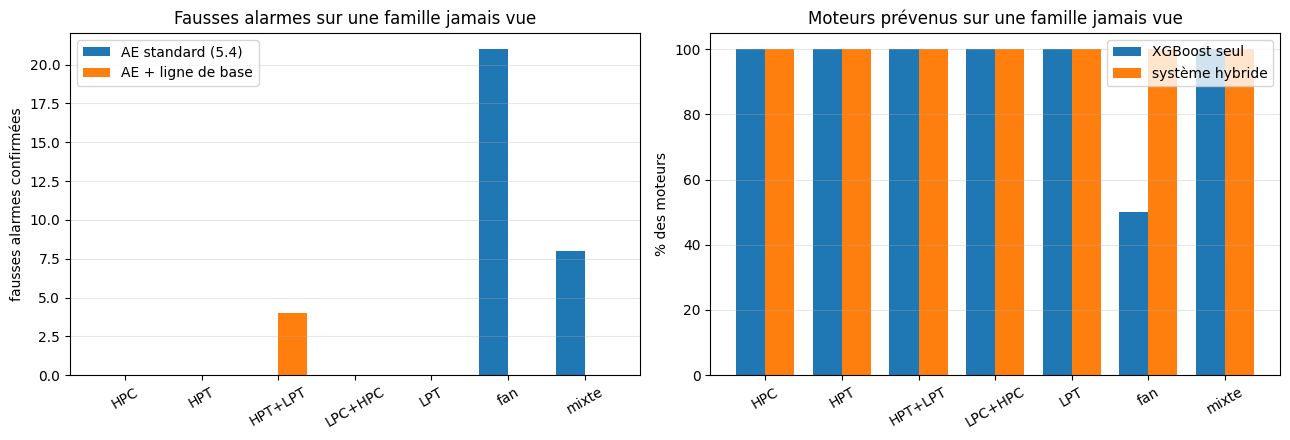

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
positions = np.arange(len(hybride))
largeur = 0.38
axes[0].bar(positions - largeur / 2, hybride["ae_standard_fausses_alarmes"], largeur, label="AE standard (5.4)")
axes[0].bar(positions + largeur / 2, hybride["ae_centre_fausses_alarmes"], largeur, label="AE + ligne de base")
axes[0].set_title("Fausses alarmes sur une famille jamais vue")
axes[0].set_ylabel("fausses alarmes confirmées")
pourcentage = lambda colonne: 100 * hybride[colonne] / hybride["moteurs"]
axes[1].bar(positions - largeur / 2, pourcentage("xgb_detectes"), largeur, label="XGBoost seul")
axes[1].bar(positions + largeur / 2, pourcentage("hybride_detectes"), largeur, label="système hybride")
axes[1].set_title("Moteurs prévenus sur une famille jamais vue")
axes[1].set_ylabel("% des moteurs")
for axe in axes:
    axe.set_xticks(positions, hybride.index, rotation=30)
    axe.legend()
    axe.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/55_systeme_hybride.png", dpi=150)
plt.show()

In [6]:
from aeroguard.hybride import etat_hybride

d = details["fan"]
table_fan = infos_hors_test[d["evaluation"]].assign(
    y=y_np[d["evaluation"]], etat=etat_hybride(d["conf_xgb"], d["conf_ae"]))
premiere_alerte = (table_fan[table_fan["etat"] != "normal"].sort_values("cycle")
                   .groupby("moteur").first()[["RUL", "etat", "y"]]
                   .rename(columns={"RUL": "RUL_1re_alerte", "etat": "1er_etat", "y": "vol_deja_use"}))
print("Première alerte de chaque moteur fan (famille jamais vue) :")
display(premiere_alerte)
print("\nNombre de vols dans chaque état, par moteur :")
pd.crosstab(table_fan["moteur"], table_fan["etat"])

Première alerte de chaque moteur fan (famille jamais vue) :


,RUL_1re_alerte,1er_etat,vol_deja_use
moteur,,,
DS04_1,33,anomalie inconnue,1
DS04_2,34,anomalie inconnue,1
DS04_3,36,anomalie inconnue,1
DS04_4,23,anomalie inconnue,1
DS04_5,72,anomalie inconnue,1
DS04_6,40,anomalie inconnue,1



Nombre de vols dans chaque état, par moteur :


etat,anomalie inconnue,normal,usure confirmée
moteur,,,
DS04_1,7,43,27
DS04_2,35,28,0
DS04_3,25,53,12
DS04_4,24,35,0
DS04_5,60,30,0
DS04_6,23,32,18


In [7]:
from aeroguard.explication import importance_par_capteur

COMPOSANT_DU_CAPTEUR = {
    "P15": "fan", "P21": "fan", "Nf": "fan", "T24": "compresseur BP (LPC)", "P24": "compresseur BP (LPC)",
    "T30": "compresseur HP (HPC)", "Ps30": "compresseur HP (HPC)", "P40": "compresseur HP (HPC)",
    "Nc": "cœur (HPC / HPT)", "T48": "turbine HP (HPT)", "T50": "turbine BP (LPT)", "P50": "turbine BP (LPT)",
    "Wf": "carburant (tout le moteur)", "P2": "entrée d'air",
}
lignes = []
for famille_retiree, d in details.items():
    y_eval = y_np[d["evaluation"]]
    vols_alertes = (d["conf_ae"] == 1) & (y_eval == 1)
    if vols_alertes.sum() == 0:
        vols_alertes = y_eval == 1
    par_capteur = importance_par_capteur(d["erreurs_feat"][vols_alertes].mean(axis=0), X_hors_test.columns)
    top = list(par_capteur.index[:3])
    lignes.append({"famille_reelle": famille_retiree, "capteur_1": top[0], "capteur_2": top[1],
                   "capteur_3": top[2], "composant_suggere": COMPOSANT_DU_CAPTEUR.get(top[0], "?")})
diagnostic = pd.DataFrame(lignes).set_index("famille_reelle")
diagnostic

,capteur_1,capteur_2,capteur_3,composant_suggere
famille_reelle,,,,
HPC,Nc,T30,T48,cœur (HPC / HPT)
HPT,T48,T50,Nc,turbine HP (HPT)
HPT+LPT,T48,T50,Nc,turbine HP (HPT)
LPC+HPC,Nc,T30,T48,cœur (HPC / HPT)
LPT,T50,T48,Nc,turbine BP (LPT)
fan,P21,P15,Nc,fan
mixte,T50,T48,T30,turbine BP (LPT)


In [8]:
hybride.to_csv(f"{DOSSIER}/results/v5_systeme_hybride.csv")
diagnostic.to_csv(f"{DOSSIER}/results/v5_diagnostic_capteurs.csv")

mlflow.set_experiment("aeroguard-anomalies")
with mlflow.start_run(run_name="systeme_hybride") as run:
    mlflow.log_params({"ligne_de_base": f"{N_PREMIERS} premiers vols de chaque moteur",
                       "hybride": "alerte = XGBoost OU autoencodeur centré",
                       "xgboost": f"seuil {SEUIL_XGB}, k {K_XGB}", "autoencodeur": f"p{PERCENTILE_AE}, k {K_AE}"})
    totaux = hybride.sum(numeric_only=True)
    mlflow.log_metrics({
        "fausses_alarmes_ae_standard": totaux["ae_standard_fausses_alarmes"],
        "fausses_alarmes_ae_centre": totaux["ae_centre_fausses_alarmes"],
        "fausses_alarmes_xgb": totaux["xgb_fausses_alarmes"],
        "fausses_alarmes_hybride": totaux["hybride_fausses_alarmes"],
        "detectes_xgb_pct": 100 * totaux["xgb_detectes"] / totaux["moteurs"],
        "detectes_hybride_pct": 100 * totaux["hybride_detectes"] / totaux["moteurs"],
    })
    for chemin in [f"{DOSSIER}/results/figures/55_systeme_hybride.png", f"{DOSSIER}/results/v5_systeme_hybride.csv",
                   f"{DOSSIER}/results/v5_diagnostic_capteurs.csv"]:
        mlflow.log_artifact(chemin)
    mlflow.set_tags({"lecon": "5.5", "tache": "anomalie", "jeu": "train+validation, famille retirée"})
print("✅ Run enregistré :", run.info.run_id[:8])

✅ Run enregistré : 912c1f34


In [9]:
dossiers_artifacts = set()
for experience in mlflow.search_experiments():
    emplacement = experience.artifact_location.replace("file://", "")
    if emplacement.startswith("/content") and not emplacement.startswith("/content/drive"):
        dossiers_artifacts.add(os.path.dirname(emplacement))

shutil.copytree(DOSSIER_MLFLOW_LOCAL, DOSSIER_MLFLOW_DRIVE, dirs_exist_ok=True)
for dossier in dossiers_artifacts:
    if os.path.exists(dossier):
        shutil.copytree(dossier, f"{DOSSIER}/{os.path.basename(dossier)}", dirs_exist_ok=True)
print("✅ MLflow sauvegardé sur Drive")

✅ MLflow sauvegardé sur Drive
